In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import os



In [4]:
path_sub = Path('sampled.ndjson')
df_sub = pd.read_json(path_sub, lines= True) 
df_sub.head()



,id,author,created_utc,ups,downs,likes,num_comments,selftext,title,subreddit,best_topic_index,best_topic,best_topic_similarity
0,1dc82va,clonedhuman,1717977620000,1,0,NaN,2,,Republicans Try To Block 4 Million Workers Fro...,politics,2,The federal minimum wage should be increased.,0.404026
1,1dcetz6,Kate_Matthews,1718000389000,1071,0,NaN,96,,US pushes for $50 billion loan to Ukraine usin...,politics,3,The US should provide financial and military a...,0.616209
2,1dch1vs,LbextDipsBenchPlatty,1718010068000,1,0,NaN,1,,The risks of AI could be catastrophic. We shou...,politics,17,Artificial Intelligence should replace humans ...,0.517387
3,1dcjmbw,eustachian_lube,1718020314000,0,0,NaN,43,,The California Minimum-Wage Disaster,politics,2,The federal minimum wage should be increased.,0.603124
4,1dcngsr,Ok-Story-9319,1718031298000,1,0,NaN,1,[removed],The U.S. Economy is Absolutely Fantastic,politics,4,A universal basic income would kill the economy.,0.458117


In [5]:
subreddit_dist = (
    df_sub["subreddit"]
    .value_counts(dropna=False)
    .rename_axis("subreddit")
    .reset_index(name="count")
)

subreddit_dist["share"] = subreddit_dist["count"] / subreddit_dist["count"].sum()

subreddit_dist

,subreddit,count,share
0,AskReddit,2019,0.64608
1,worldnews,436,0.13952
2,Conservative,239,0.07648
3,changemyview,154,0.04928
4,PoliticalDiscussion,111,0.03552
5,AmItheAsshole,105,0.03360
6,moderatepolitics,19,0.00608
7,politics,16,0.00512
8,Liberal,14,0.00448
9,Debate,9,0.00288


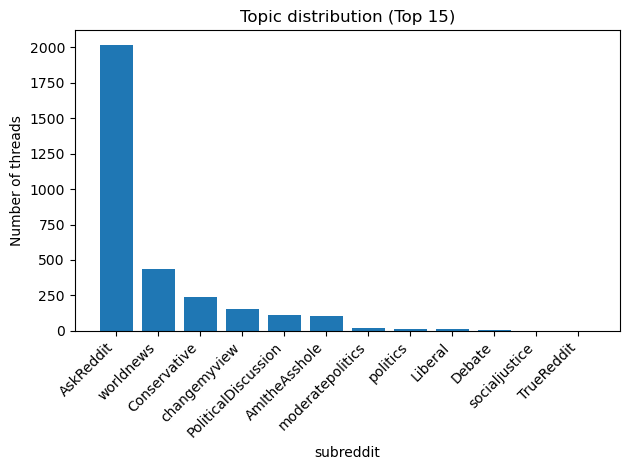

In [6]:
top_n = 15
plot_df = subreddit_dist.head(top_n)

plt.figure()
plt.bar(plot_df["subreddit"].astype(str), plot_df["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Topic distribution (Top {})".format(top_n))
plt.ylabel("Number of threads")
plt.xlabel("subreddit")
plt.tight_layout()
plt.show()

In [7]:
path_merged = Path("data/conversation_threads_flat.ndjson")
df_merged = pd.read_json(path_merged, lines=True)
df_merged

,thread_id,submission_id,root_id,comment_id,parent_id,link_id,body,user,score,created_utc,...,depth,submission_title,submission_selftext,submission_author,submission_score,submission_created_utc,submission_subreddit,submission_url,best_topic_index,best_topic_similarity
0,1dc82va,1dc82va,l7w2bxm,l7w2bxm,1dc82va,1dc82va,"\nAs a reminder, this subreddit [is for civil ...",AutoModerator,1,1717977620,...,0,Republicans Try To Block 4 Million Workers Fro...,,clonedhuman,NaN,1717977620000,politics,NaN,2,0.404026
1,1dc82va,1dc82va,l7w2fvc,l7w2fvc,1dc82va,1dc82va,Hi `clonedhuman`. Thank you for participating ...,PoliticsModeratorBot,1,1717977666,...,0,Republicans Try To Block 4 Million Workers Fro...,,clonedhuman,NaN,1717977620000,politics,NaN,2,0.404026
2,1dgr2cw,1dgr2cw,l8trvbz,l8trvbz,1dgr2cw,1dgr2cw,There's a growing number of people who never k...,Drakeytown,3,1718518626,...,0,Can't people see that social media spreads mis...,"I'm 48. I grew up not knowing the internet, ce...",Rainbow_Hope,NaN,1718483962000,socialjustice,NaN,18,0.528062
3,1dgr2cw,1dgr2cw,l8trvbz,l8uo7rf,l8trvbz,1dgr2cw,Thanks.,Rainbow_Hope,2,1718540893,...,1,Can't people see that social media spreads mis...,"I'm 48. I grew up not knowing the internet, ce...",Rainbow_Hope,NaN,1718483962000,socialjustice,NaN,18,0.528062
4,1do7blq,1do7blq,la7kwyu,la7kwyu,1do7blq,1do7blq,\nRemember that TrueReddit is a place to engag...,AutoModerator,1,1719325626,...,0,Nutrition influencers claim we should eat meat...,,scientificamerican,NaN,1719325626000,TrueReddit,NaN,8,0.415957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125084,1dvks92,1dvks92,lbo85pk,lbo8bmk,lbo85pk,1dvks92,"And leaving the drivers good tips lol, when I ...",TazzzTM,1,1720137470,...,1,"In 2024, what is a subtle sign that someone ha...",,NeatEhEff,NaN,1720137357000,AskReddit,NaN,4,0.461690
125085,1dvks92,1dvks92,lbo85pk,lbo8izq,lbo8bmk,1dvks92,I’ve left 20s before lmao I’m just very gratef...,YourWickedUncleErnie,2,1720137559,...,2,"In 2024, what is a subtle sign that someone ha...",,NeatEhEff,NaN,1720137357000,AskReddit,NaN,4,0.461690
125086,1dvks92,1dvks92,lbo85pk,lbo8egj,lbo85pk,1dvks92,My first thought too,motherofvoids_,1,1720137504,...,1,"In 2024, what is a subtle sign that someone ha...",,NeatEhEff,NaN,1720137357000,AskReddit,NaN,4,0.461690
125087,1dvks92,1dvks92,lbo8eah,lbo8eah,1dvks92,1dvks92,Just grabbing stuff off the shelf at the store...,Adorable-bank34,1,1720137502,...,0,"In 2024, what is a subtle sign that someone ha...",,NeatEhEff,NaN,1720137357000,AskReddit,NaN,4,0.461690


In [8]:
subreddit_dist1 = (
    df_merged["submission_subreddit"]
    .value_counts(dropna=False)
    .rename_axis("subreddit")
    .reset_index(name="count")
)

subreddit_dist1["share"] = subreddit_dist1["count"] / subreddit_dist1["count"].sum()

subreddit_dist1

,subreddit,count,share
0,worldnews,65226,0.521437
1,AskReddit,31209,0.249494
2,changemyview,13705,0.109562
3,Conservative,6183,0.049429
4,AmItheAsshole,3200,0.025582
5,moderatepolitics,2791,0.022312
6,PoliticalDiscussion,2266,0.018115
7,Liberal,336,0.002686
8,TrueReddit,145,0.001159
9,Debate,24,0.000192


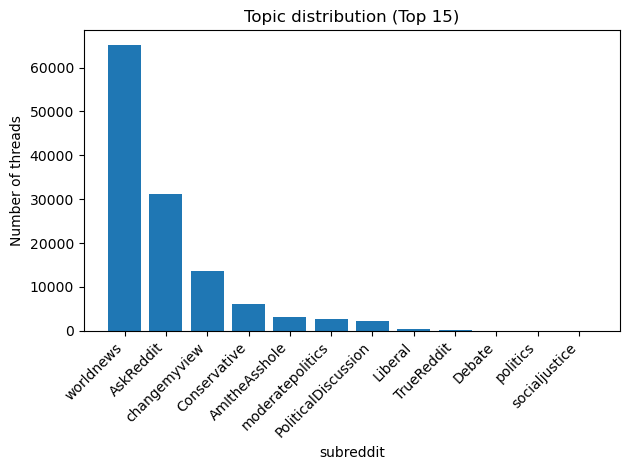

In [9]:
top_n = 15
plot_df = subreddit_dist1.head(top_n)

plt.figure()
plt.bar(plot_df["subreddit"].astype(str), plot_df["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Topic distribution (Top {})".format(top_n))
plt.ylabel("Number of threads")
plt.xlabel("subreddit")
plt.tight_layout()
plt.show()